# RAG Part 2: Embeddings Visualizer
## See How AI Understands Meaning

In Part 1, we found relevant documents by **counting matching words**.

That worked, but it has a problem: what if the user asks about "model storage requirements" instead of "disk space"? No word match, no result!

In this notebook, we'll use **embeddings** — a smarter way to find similar meaning.

**Let's start by seeing the result, then we'll explain how it works.**

---
## Setup

In [1]:
# Install sentence-transformers if needed
try:
    from sentence_transformers import SentenceTransformer
except ImportError:
    %pip install sentence-transformers --break-system-packages
    from sentence_transformers import SentenceTransformer

import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
# Same 5 documents from Part 1
documents = [
    "The SmallLM course at UC Berkeley was created in Fall 2025 by the discovery program team.",
    "Professor Greg Merritt designed the Ollama demo to teach students to run AI models locally.",
    "The Qwen2 1.5B model uses Q4_0 quantization and requires only 894 MB of disk space.",
    "TinyLlama 1.1B was trained on 3 trillion tokens despite having only 1.1 billion parameters.",
    "JupyterCon 2025 hosted a workshop on teaching economics students about AI inference costs."
]

# Short labels for plotting
labels = ["SmallLM Course", "Ollama Demo", "Qwen2 Model", "TinyLlama", "JupyterCon"]

In [3]:
# Load embedding model (this may take a moment the first time)
print("Loading embedding model...")
embed_model = SentenceTransformer('all-MiniLM-L6-v2')  # Small, fast, good quality
print("Done!")

Loading embedding model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Done!


In [4]:
# Create embeddings for all documents
doc_embeddings = embed_model.encode(documents)
print(f"Created {len(doc_embeddings)} embeddings")
print(f"Each embedding has {len(doc_embeddings[0])} dimensions")

Created 5 embeddings
Each embedding has 384 dimensions


---
## The Big Picture: Documents in Space

Each document is now a point in space. **Similar documents are close together.**

Let's see it!

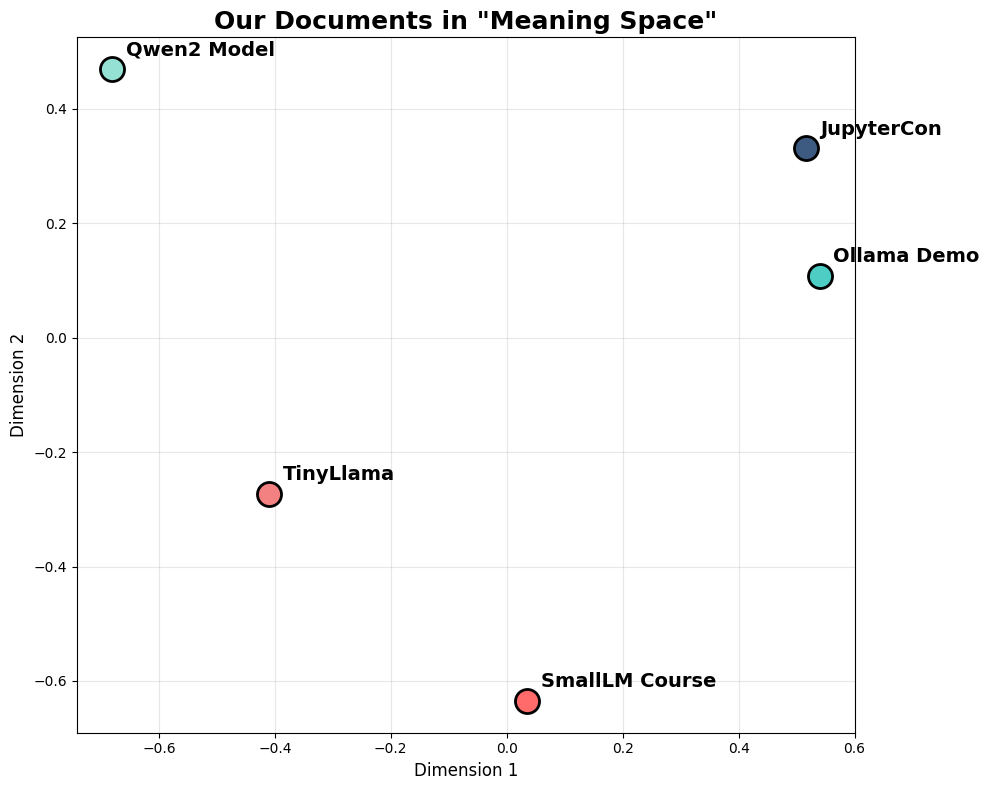

In [5]:
# Reduce to 2D for visualization (embeddings have 384 dimensions, we can only see 2)
# PCA is deterministic and stable — documents stay in the same position across all plots
pca = PCA(n_components=2)
doc_2d = pca.fit_transform(doc_embeddings)

# Plot!
fig, ax = plt.subplots(figsize=(10, 8))

# Define colors for each document
colors = ['#FF6B6B', '#4ECDC4', '#95E1D3', '#F38181', '#3D5A80']

# Plot each document as a point
for i, (x, y) in enumerate(doc_2d):
    ax.scatter(x, y, s=300, c=colors[i], edgecolors='black', linewidths=2, zorder=2)
    ax.annotate(labels[i], (x, y), fontsize=14, fontweight='bold',
                xytext=(10, 10), textcoords='offset points')

ax.set_title('Our Documents in "Meaning Space"', fontsize=18, fontweight='bold')
ax.set_xlabel('Dimension 1', fontsize=12)
ax.set_ylabel('Dimension 2', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**What do you notice?**

Documents about similar topics should be closer together. For example, the two model-related documents (Qwen2 and TinyLlama) should cluster near each other, while the teaching-related documents (SmallLM Course, Ollama Demo, JupyterCon) should form another group.

good read: https://colah.github.io/posts/2014-07-NLP-RNNs-Representations/

---
## How Did We Get Here?

### What is an embedding?

An embedding is just a **list of numbers** that represents the meaning of text.

In [6]:
# Let's see the embedding for the first document
first_embedding = doc_embeddings[0]

print(f"The embedding for the SmallLM Course document:")
print(f"Length: {len(first_embedding)} numbers")
print(f"")
print(f"First 10 numbers: {first_embedding[:10].round(3)}")
print(f"...")
print(f"Last 10 numbers:  {first_embedding[-10:].round(3)}")

The embedding for the SmallLM Course document:
Length: 384 numbers

First 10 numbers: [ 0.012 -0.04   0.011  0.049 -0.006  0.037 -0.097 -0.027 -0.055  0.1  ]
...
Last 10 numbers:  [ 0.048  0.127 -0.023 -0.141 -0.044  0.011 -0.063  0.028 -0.032  0.021]


**384 numbers!** That's a lot. Each number captures some aspect of the meaning.

We can't visualize 384 dimensions, so we used PCA (Principal Component Analysis) to squish it down to 2D for the plot above. But the computer works with all 384.

---
## Now: Add a Question to the Map

When a user asks a question, we:
1. Turn the question into an embedding
2. Find which document embeddings are closest

Let's see this visually!

In [7]:
# Our question
question = "How big is the Qwen2 model file?"

# Turn question into embedding
question_embedding = embed_model.encode([question])[0]

print(f"Question: {question}")
print(f"Question embedding: {len(question_embedding)} numbers")

Question: How big is the Qwen2 model file?
Question embedding: 384 numbers


In [8]:
# Calculate similarity between question and each document
similarities = cosine_similarity([question_embedding], doc_embeddings)[0]

print("Similarity scores:")
for label, sim in zip(labels, similarities):
    print(f"  {label}: {sim:.3f}")

best_match = labels[np.argmax(similarities)]
print(f"\nBest match: {best_match}")

Similarity scores:
  SmallLM Course: 0.134
  Ollama Demo: 0.151
  Qwen2 Model: 0.746
  TinyLlama: 0.235
  JupyterCon: 0.094

Best match: Qwen2 Model


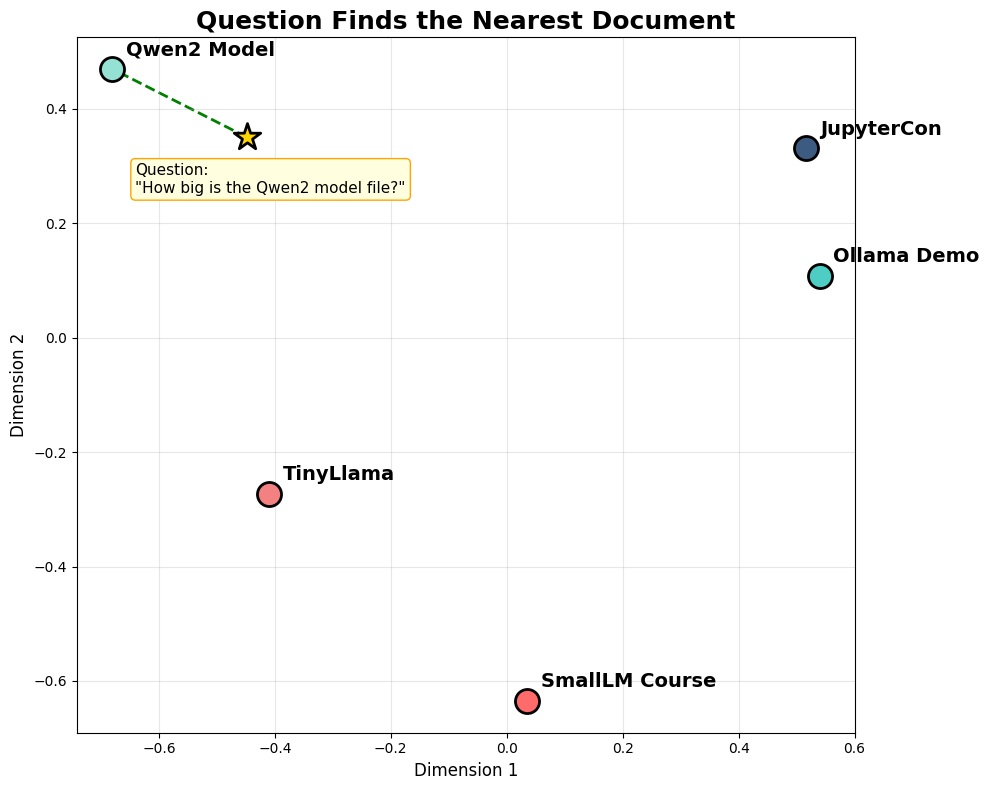

In [ ]:
# Project the question into the same 2D space
# We use pca.transform() so documents stay in the same positions as before
q_2d = pca.transform([question_embedding])[0]

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# Plot documents (same positions as the previous plot!)
for i, (x, y) in enumerate(doc_2d):
    ax.scatter(x, y, s=300, c=colors[i], edgecolors='black', linewidths=2, zorder=2)
    ax.annotate(labels[i], (x, y), fontsize=14, fontweight='bold',
                xytext=(10, 10), textcoords='offset points')

ax.scatter(q_2d[0], q_2d[1], s=400, c='gold', marker='*', 
           edgecolors='black', linewidths=2, zorder=3)
ax.annotate(f'Question:\n"{question}"', (q_2d[0], q_2d[1]), fontsize=11,
            xytext=(-80, -40), textcoords='offset points',
            bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='orange'))

# Draw line to best match
best_idx = np.argmax(similarities)
ax.plot([q_2d[0], doc_2d[best_idx][0]], [q_2d[1], doc_2d[best_idx][1]], 
        'g--', linewidth=2, zorder=1)

ax.set_title('Question Finds the Nearest Document', fontsize=18, fontweight='bold')
ax.set_xlabel('Dimension 1', fontsize=12)
ax.set_ylabel('Dimension 2', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**The question lands near the Qwen2 Model document!** 

The embedding model understood that "How big is the Qwen2 model file?" is related to the document about Qwen2's disk space and quantization.

---
## The Magic semantics!

Here's where embeddings shine. Let's try a question that uses **different words** but means the same thing.

Remember from Part 1: word-matching would FAIL here because there's no word overlap!

In [10]:
# A question using DIFFERENT words
tricky_question = "What are the storage needs for the quantized neural network?"

print(f"Tricky question: {tricky_question}")
print(f"")
print(f"Notice: No mention of 'Qwen2', 'disk space', '894 MB', or 'model'!")
print(f"Word-matching would fail here.")

Tricky question: What are the storage needs for the quantized neural network?

Notice: No mention of 'Qwen2', 'disk space', '894 MB', or 'model'!
Word-matching would fail here.


In [11]:
# Let's compare: Word Matching vs Embeddings
import re

# --- Word Matching (from Part 1) ---
def simple_similarity(question, document):
    # Remove punctuation so "sleep?" matches "sleep"
    question_clean = re.sub(r'[^\w\s]', '', question.lower())
    document_clean = re.sub(r'[^\w\s]', '', document.lower())
    
    question_words = set(question_clean.split())
    document_words = set(document_clean.split())
    
    # Remove common "stop words" that don't carry meaning
    stop_words = {'how', 'much', 'do', 'does', 'the', 'a', 'an', 'is', 'are',
                  'what', 'which', 'who', 'where', 'when', 'can', 'tell', 'me',
                  'about', 'and', 'or', 'to', 'in', 'of', 'for', 'that', 'they',
                  'it', 'i', 'want', 'their'}
    question_words -= stop_words
    
    common_words = question_words & document_words
    if len(question_words) == 0:
        return 0
    return len(common_words) / len(question_words)

word_scores = [simple_similarity(tricky_question, doc) for doc in documents]

# --- Embeddings ---
tricky_embedding = embed_model.encode([tricky_question])[0]
embed_scores = cosine_similarity([tricky_embedding], doc_embeddings)[0]

# Show comparison
print(f"Question: \"{tricky_question}\"")
print(f"")
print(f"{'Document':<12} {'Word Match':<12} {'Embedding':<12}")
print(f"-" * 36)
for label, ws, es in zip(labels, word_scores, embed_scores):
    print(f"{label:<12} {ws:<12.3f} {es:<12.3f}")

Question: "What are the storage needs for the quantized neural network?"

Document     Word Match   Embedding   
------------------------------------
SmallLM Course 0.000        0.085       
Ollama Demo  0.000        0.119       
Qwen2 Model  0.000        0.439       
TinyLlama    0.000        0.257       
JupyterCon   0.000        0.176       


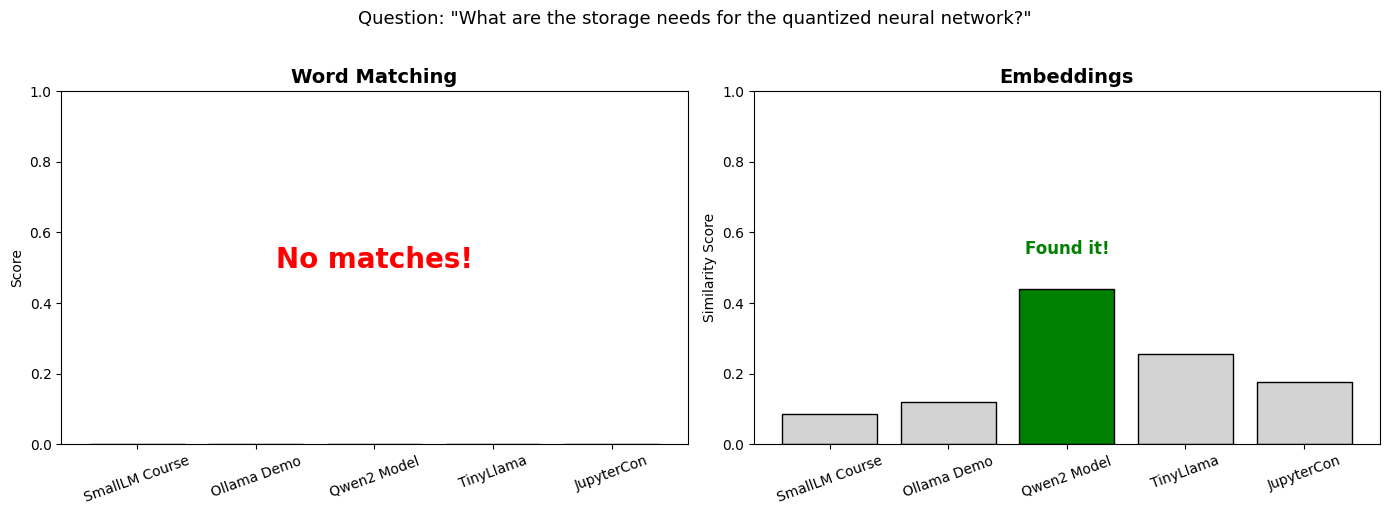


Embeddings found the right document even without matching words!
It understood that 'storage needs' = 'disk space' and 'quantized neural network' = 'Q4_0 quantization model'


In [12]:
# Visualize the comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Word Matching
word_colors = ['green' if s == max(word_scores) and s > 0 else 'lightgray' for s in word_scores]
axes[0].bar(labels, word_scores, color=word_colors, edgecolor='black')
axes[0].set_title('Word Matching', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)

# Add "No matches!" annotation if all scores are 0
if max(word_scores) == 0:
    axes[0].text(2, 0.5, 'No matches!', fontsize=20, ha='center', 
                 color='red', fontweight='bold')

# Embeddings
embed_colors = ['green' if s == max(embed_scores) else 'lightgray' for s in embed_scores]
axes[1].bar(labels, embed_scores, color=embed_colors, edgecolor='black')
axes[1].set_title('Embeddings', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Similarity Score')
axes[1].set_ylim(0, 1)
axes[1].tick_params(axis='x', rotation=20)

# Highlight winner
best_embed = labels[np.argmax(embed_scores)]
axes[1].annotate(f'Found it!', xy=(np.argmax(embed_scores), max(embed_scores)),
                 xytext=(np.argmax(embed_scores), max(embed_scores) + 0.1),
                 fontsize=12, ha='center', color='green', fontweight='bold')

plt.suptitle(f'Question: "{tricky_question}"', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nEmbeddings found the right document even without matching words!")
print(f"It understood that 'storage needs' = 'disk space' and 'quantized neural network' = 'Q4_0 quantization model'")

---
## Try It Yourself!

Try different questions and see where they land on the map.

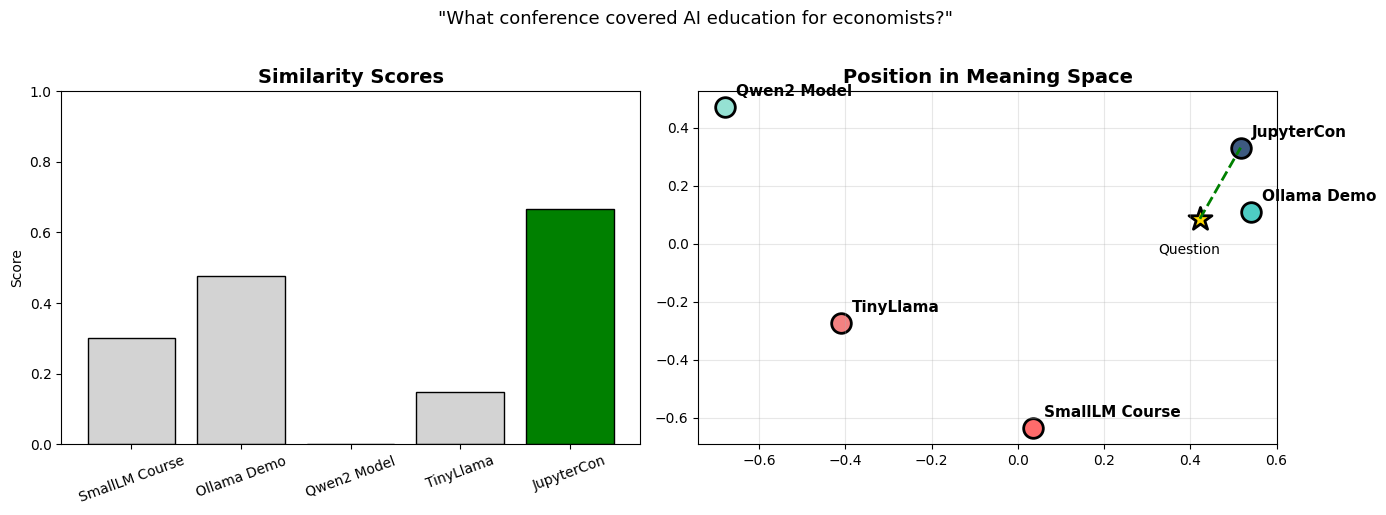

Best match: JupyterCon (score: 0.667)


In [16]:
# TRY DIFFERENT QUESTIONS:
# - "Who teaches the local AI class at Berkeley?"
# - "How much training data did the small language model use?"
# - "What conference covered AI education for economists?"
# - "How can I run LLMs without an internet connection?"

my_question = "What conference covered AI education for economists?"  # <-- CHANGE THIS!

# Get embedding and scores
q_embed = embed_model.encode([my_question])[0]
scores = cosine_similarity([q_embed], doc_embeddings)[0]

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Bar chart of scores
bar_colors = ['green' if s == max(scores) else 'lightgray' for s in scores]
axes[0].bar(labels, scores, color=bar_colors, edgecolor='black')
axes[0].set_title('Similarity Scores', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=20)

# Right: 2D plot — project question into the same PCA space (documents stay fixed)
q2d = pca.transform([q_embed])[0]

for i, (x, y) in enumerate(doc_2d):
    axes[1].scatter(x, y, s=200, c=colors[i], edgecolors='black', linewidths=2)
    axes[1].annotate(labels[i], (x, y), fontsize=11, fontweight='bold',
                     xytext=(8, 8), textcoords='offset points')

axes[1].scatter(q2d[0], q2d[1], s=300, c='gold', marker='*', edgecolors='black', linewidths=2)
axes[1].annotate('Question', (q2d[0], q2d[1]), fontsize=10,
                 xytext=(-30, -25), textcoords='offset points')

best_idx = np.argmax(scores)
axes[1].plot([q2d[0], doc_2d[best_idx][0]], [q2d[1], doc_2d[best_idx][1]], 'g--', linewidth=2)
axes[1].set_title('Position in Meaning Space', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'"{my_question}"', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Best match: {labels[best_idx]} (score: {scores[best_idx]:.3f})")

---
## Two Key Ideas

### Similar meaning = close in space

Embeddings turn text into coordinates. Documents about similar topics end up near each other. Questions land near the documents that can answer them.

### Embeddings capture semantics, not just keywords

Unlike word-matching, embeddings understand that:
- "storage needs" ≈ "disk space"
- "quantized neural network" ≈ "Q4_0 quantization model"
- "local AI class" ≈ "Ollama demo to teach students"

This is why modern search and RAG systems use embeddings!